In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model=ChatGoogleGenerativeAI(model='gemini-3.6-flash')

In [5]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

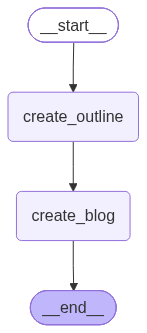

In [9]:
workflow

In [10]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'Here is a detailed, SEO-friendly outline for a blog post on **"The Rise of AI in India."** \n\n---\n\n# **Blog Title Ideas:**\n1. From IT Hub to AI Powerhouse: The Rise of Artificial Intelligence in India\n2. India’s AI Revolution: How Artificial Intelligence is Transforming the Next Billion Users\n3. AI in India: Market Drivers, Sectoral Impact, and the Road Ahead\n4. The #AIforAll Vision: How India is Building a Unique AI Ecosystem\n\n---\n\n### **Meta Description (SEO):**\nDiscover how India is transitioning from a global IT outsourcing hub to a leader in Artificial Intelligence. Explore key drivers, sector impacts, Indic LLMs, government policies, and future challenges in this detailed analysis.\n\n---\n\n## **I. Introduction**\n*   **Hook:** Start with a compelling stat or scenario (e.g., a farmer in rural Maharashtra using a voice-based AI app in Marathi to check crop prices, or India\'s projected $500 billion